<a href="https://colab.research.google.com/github/Uwater1/kaggle/blob/main/kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Upload kaggle.json

In [ ]:
# 1. Read the kaggle API token to interact with your kaggle account

from google.colab import files
files.upload()

## Or use the kaggle.json or kaggle.zip in Google Drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
!cp drive/MyDrive/kaggle.json .
!cp drive/MyDrive/kaggle.zip .
!if [ -f kaggle.json ]; then exit 1; fi; unzip kaggle.zip


In [1]:
!ls -lha kaggle.json
!pip install -q kaggle # installing the kaggle package
!mkdir -p ~/.kaggle # creating .kaggle folder where the key should be placed
!cp kaggle.json ~/.kaggle/ # move the key to the folder
!pwd # checking the present working directory

ls: cannot access 'kaggle.json': No such file or directory
cp: cannot stat 'kaggle.json': No such file or directory
/content


In [9]:
!chmod 600 /root/.kaggle/kaggle.json
!kaggle competitions download -c titanic #Replace titanic with your name
!unzip titanic.zip

  0% 0.00/34.1k [00:00<?, ?B/s]
100% 34.1k/34.1k [00:00<00:00, 126MB/s]
Archive:  titanic.zip
  inflating: gender_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [10]:
import pandas as pd

# Load the train.csv file into a DataFrame
try:
    df_train = pd.read_csv('train.csv')
    print("Successfully loaded 'train.csv'")
except FileNotFoundError:
    print("Error: 'train.csv' not found. Download it from Kaggle.")
    df_train = None # Set to None to avoid further errors if file not found

Successfully loaded 'train.csv'


### First 5 rows of the DataFrame:

In [22]:
if df_train is not None:
    display(df_train)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck,Cabin_Count,Title,FamilySize,IsAlone,Log_Fare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,M,0,Mr,2,0,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C,1,Mrs,2,0,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,M,0,Miss,1,1,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,C,1,Mrs,2,0,3.990834
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,M,0,Mr,1,1,2.202765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,M,0,Rare,1,1,2.639057
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,B,1,Miss,1,1,3.433987
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,M,0,Miss,4,0,3.196630
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,C,1,Mr,1,1,3.433987


### Basic information about the DataFrame (columns, non-null counts, data types):

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Define target variable 'y'
y = df_train['Survived']

# Define features 'X'
# Drop identifier, name, ticket, and cabin columns which are generally not used directly as features or require extensive engineering
X = df_train.drop(['Survived', 'PassengerId', 'Name', 'Ticket'], axis=1)

# Handle categorical features: one-hot encode 'Sex' and 'Embarked'
X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)

# Impute missing 'Age' values with the mean for simplicity
if 'Age' in X.columns:
    X['Age'].fillna(X['Age'].mean(), inplace=True)

# Perform the train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

--- Cabin Deck Statistical Description ---
      Count  Survival_Rate  Avg_Pclass  Avg_Fare
Deck                                            
M       687           0.30        2.64     19.16
C        59           0.59        1.00    100.15
B        47           0.74        1.00    113.51
D        33           0.76        1.12     57.24
E        32           0.75        1.31     46.03
A        15           0.47        1.00     39.62
F        13           0.62        2.38     18.70
G         4           0.50        3.00     13.58
T         1           0.00        1.00     35.50


/tmp/ipython-input-2813203156.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Deck', y='Survived', palette='viridis', order=sorted(df['Deck'].unique()))


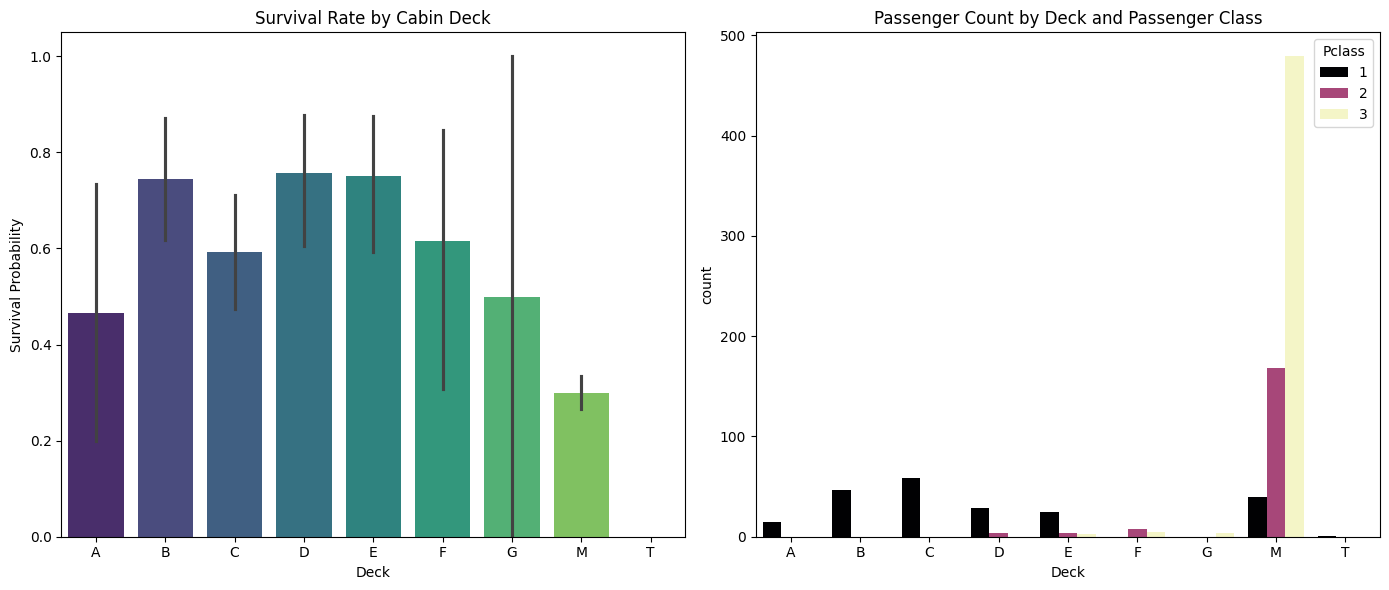

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def properly_describe_cabin(df):
    """
    Analyzes and processes the 'Cabin' feature by extracting Deck and Room Count.
    """
    # 1. Feature Extraction: Deck (First letter)
    # We use 'M' (Missing) for passengers without a cabin record
    df['Deck'] = df['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')

    # 2. Feature Extraction: Cabin Count
    # Some passengers have multiple cabins (e.g., 'C23 C25 C27')
    df['Cabin_Count'] = df['Cabin'].apply(lambda s: len(s.split()) if pd.notnull(s) else 0)

    # 3. Statistical Analysis
    # Group by Deck to see survival rates, average Class, and average Fare
    cabin_analysis = df.groupby('Deck').agg({
        'Survived': ['count', 'mean'],
        'Pclass': 'mean',
        'Fare': 'mean'
    }).round(2)
    
    # Rename columns for clarity
    cabin_analysis.columns = ['Count', 'Survival_Rate', 'Avg_Pclass', 'Avg_Fare']
    
    print("--- Cabin Deck Statistical Description ---")
    print(cabin_analysis.sort_values(by='Count', ascending=False))

    # 4. Visualization
    plt.figure(figsize=(14, 6))

    # Survival Rate by Deck
    plt.subplot(1, 2, 1)
    sns.barplot(data=df, x='Deck', y='Survived', palette='viridis', order=sorted(df['Deck'].unique()))
    plt.title('Survival Rate by Cabin Deck')
    plt.ylabel('Survival Probability')

    # Distribution of Decks across Classes
    plt.subplot(1, 2, 2)
    sns.countplot(data=df, x='Deck', hue='Pclass', palette='magma', order=sorted(df['Deck'].unique()))
    plt.title('Passenger Count by Deck and Passenger Class')

    plt.tight_layout()
    plt.show()

# Run the description
if 'df_train' in locals() and df_train is not None:
    properly_describe_cabin(df_train)


In [29]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Load Data
train_df = pd.read_csv('train.csv')

def preprocess_titanic(df):
    # --- A. Missingness Indicators ---
    df['Age_is_missing'] = df['Age'].isnull().astype(int)
    df['Fare_is_missing'] = df['Fare'].isnull().astype(int)
    
    # --- B. Name & Identity Features ---
    df['Name_Length'] = df['Name'].apply(len)
    # Fixed: Added 'r' before string to fix SyntaxWarning
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss').replace('Mme', 'Mrs')
    
    # --- C. Family & Group Dynamics ---
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    df['Ticket_Freq'] = df.groupby('Ticket')['Ticket'].transform('count')
    
    # --- D. Cabin & Deck Features ---
    df['Deck'] = df['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')
    df['Cabin_Count'] = df['Cabin'].apply(lambda s: len(s.split()) if pd.notnull(s) else 0)
    
    # --- E. Advanced Numerical Features ---
    df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    
    df['IsChild'] = (df['Age'] < 16).astype(int)
    df['Age_Class_Interaction'] = df['Age'] * df['Pclass']
    df['Fare_Per_Person'] = df['Fare'] / df['FamilySize']
    
    # --- F. Selection and Encoding ---
    cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
    df = df.drop(cols_to_drop, axis=1)
    
    # Categorical encoding
    df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title', 'Deck'])
    return df

# Process Train
full_train = preprocess_titanic(train_df)
X = full_train.drop(['Survived'], axis=1)
y = full_train['Survived']

model_columns = X.columns.tolist()

# Split for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train XGBoost
# Fixed: Moved early_stopping_rounds to the constructor for compatibility with newer XGBoost
model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    early_stopping_rounds=50 # <-- Moved here
)

# Fixed: fit() now only takes the training and validation sets
model.fit(X_train, y_train, 
          eval_set=[(X_val, y_val)], 
          verbose=False)

# 3. Validation Performance
val_preds = model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, val_preds):.4f}")

# 4. Feature Importance
importance = pd.Series(model.feature_importances_, index=model_columns).sort_values(ascending=False)
print("\n--- Top 5 Most Important Features ---")
print(importance.head(5))



/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [10:34:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


Validation Accuracy: 0.8380

--- Top 5 Most Important Features ---
Title_Mr      0.213165
Sex_male      0.126494
Sex_female    0.117793
Pclass        0.071017
FamilySize    0.036444
dtype: float32


In [35]:
# 1. Load and Process Test Data
test_df = pd.read_csv('test.csv')
passenger_ids = test_df['PassengerId']

# Apply same preprocessing
X_test = preprocess_titanic(test_df)

# 2. Feature Alignment
# Test data might miss some categories found in Train (e.g., a specific Deck or Title)
# We add missing columns as zeros and remove any unexpected columns
for col in model_columns:
    if col not in X_test.columns:
        X_test[col] = 0

# Reorder columns to match the model training order exactly
X_test = X_test[model_columns]

# 3. Predict and Save
test_predictions = model.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": test_predictions
})

submission.to_csv('submission.csv', index=False)

print("--- Prediction Complete ---")
print(f"Generated predictions for {len(submission)} passengers.")
print("File 'submission.csv' is ready for Kaggle upload.")
display(submission.head())


--- Prediction Complete ---
Generated predictions for 418 passengers.
File 'submission.csv' is ready for Kaggle upload.


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [34]:
import pandas as pd
submit = pd.read_csv("submission.csv")
submit.describe()

,PassengerId,Survived
count,418.000000,418.000000
mean,1100.500000,0.370813
std,120.810458,0.483601
min,892.000000,0.000000
25%,996.250000,0.000000
50%,1100.500000,0.000000
75%,1204.750000,1.000000
max,1309.000000,1.000000


In [36]:
# Submit the generated CSV file to the Kaggle competition
!kaggle competitions submit -c titanic -f submission.csv -m "XGBoost model with engineered Title, Deck, and FamilySize features"


100% 2.77k/2.77k [00:00<00:00, 8.41kB/s]
Successfully submitted to Titanic - Machine Learning from Disaster